In [ ]:
%matplotlib inline
import torch
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from lorentz import Lorentz

CKPT   = 'ckpt/final_enoa_graph.ckpt'
VOCAB  = 'enoa_vocab.pkl'
COLLAB = 'code/dataset/Original/global/global-genre_network-2018.csv'
DIM    = 2

genres = pickle.load(open(VOCAB, 'rb'))
n_items = len(genres)
genre_to_idx = {g: i for i, g in enumerate(genres)}

net = Lorentz(n_items, DIM + 1)
net.load_state_dict(torch.load(CKPT, map_location='cpu'))
net.eval()

lorentz_table = net.table.weight.data.cpu().numpy()

def lorentz_scalar_product(u, v):
    return -u[0]*v[0] + np.dot(u[1:], v[1:])

def lorentz_distance(u, v):
    inner = lorentz_scalar_product(u, v)
    inner = min(inner, -1.0)
    return float(np.arccosh(-inner))

def get_embedding(genre_name):
    if genre_name not in genre_to_idx:
        return None
    return lorentz_table[genre_to_idx[genre_name] + 1]

print(f'Loaded {n_items} genres')

Loaded 6280 genres


In [3]:
collab = pd.read_csv(COLLAB, sep='\t')
collab = collab[collab['source'] != collab['target']]

rows = []
for _, row in collab.iterrows():
    u = get_embedding(row['source'])
    v = get_embedding(row['target'])
    if u is None or v is None:
        continue
    rows.append({
        'source':      row['source'],
        'target':      row['target'],
        'weight':      row['weight'],
        'avg_streams': row['avg_streams'],
        'distance':    lorentz_distance(u, v),
        'log_streams': np.log10(row['avg_streams'] + 1)
    })

df = pd.DataFrame(rows)
print(f'Pairs with embeddings: {len(df)}')
print(df[['distance', 'avg_streams']].describe().round(2))

Pairs with embeddings: 2581
       distance   avg_streams
count   2581.00  2.581000e+03
mean       4.12  8.232828e+07
std        2.10  9.270614e+07
min        0.02  3.504950e+06
25%        2.50  1.657194e+07
50%        4.09  5.320247e+07
75%        5.83  1.065834e+08
max        8.94  6.032435e+08


In [4]:
FAMILIES = {
    'Pop': ['pop', 'dance pop', 'canadian pop', 'uk pop', 'art pop',
            'post-teen pop', 'bedroom pop', 'indie pop', 'viral pop',
            'new wave pop', 'singer-songwriter pop', 'pov: indie',
            'electropop', 'k-pop', 'j-pop'],
    'Rap': ['rap', 'pop rap', 'melodic rap', 'cloud rap', 'gangster rap',
            'east coast hip hop', 'southern hip hop', 'atl hip hop',
            'french hip hop', 'west coast rap', 'conscious hip hop',
            'chicago rap', 'trap', 'atl trap'],
    'Rock': ['rock', 'modern rock', 'classic rock', 'alternative rock',
             'hard rock', 'post-grunge', 'album rock', 'soft rock',
             'indie rock', 'folk rock', 'pop rock', 'alternative metal',
             'permanent wave'],
    'Urbano Latino': ['urbano latino', 'trap latino', 'reggaeton',
                      'musica mexicana', 'corrido', 'norteno', 'sierreno',
                      'banda', 'sad sierreno', 'reggaeton colombiano',
                      'latin pop', 'latin alternative', 'latin'],
    'Hip Hop': ['hip hop', 'atl hip hop', 'southern hip hop',
                'urban contemporary', 'east coast hip hop',
                'conscious hip hop', 'french hip hop', 'german hip hop',
                'canadian hip hop', 'latin hip hop'],
    'Electronic': ['edm', 'electro house', 'house', 'progressive house',
                   'tropical house', 'slap house', 'techno', 'deep house',
                   'big room', 'brostep', 'electropop']
}

COLORS = {
    'Pop': '#e63946',
    'Rap': '#f4a261',
    'Rock': '#2a9d8f',
    'Urbano Latino': '#8338ec',
    'Hip Hop': '#457b9d',
    'Electronic': '#e9c46a'
}

def assign_families(row):
    assigned = []
    for family, members in FAMILIES.items():
        if row['source'] in members or row['target'] in members:
            assigned.append(family)
    return assigned if assigned else ['Other']

df['families'] = df.apply(assign_families, axis=1)
df_expanded = df.explode('families').rename(columns={'families': 'family'})

print('Pair counts per family:')
print(df_expanded['family'].value_counts().to_string())

Pair counts per family:
family
Rap              743
Pop              693
Other            577
Electronic       493
Hip Hop          472
Urbano Latino    160
Rock              64


In [9]:
results = []

r_g, p_g = stats.spearmanr(df['distance'], df['log_streams'])
results.append({'Family (2018)': 'GLOBAL', 'N': len(df),
                'Spearman r': round(r_g, 4), 'p-value': round(p_g, 4),
                'Significant': 'yes *' if p_g < 0.05 else 'no'})

for family in list(FAMILIES.keys()) + ['Other']:
    subset = df_expanded[df_expanded['family'] == family]
    if len(subset) < 20:
        continue
    r, p = stats.spearmanr(subset['distance'], subset['log_streams'])
    results.append({'Family (2018)': family, 'N': len(subset),
                    'Spearman r': round(r, 4), 'p-value': round(p, 4),
                    'Significant': 'yes *' if p < 0.05 else 'no'})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Family (2018)    N  Spearman r  p-value Significant
       GLOBAL 2581     -0.0005   0.9788          no
          Pop  693     -0.0811   0.0327       yes *
          Rap  743      0.1037   0.0047       yes *
         Rock   64     -0.1151   0.3651          no
Urbano Latino  160      0.1162   0.1433          no
      Hip Hop  472      0.0141   0.7593          no
   Electronic  493     -0.1384   0.0021       yes *
        Other  577      0.0545   0.1913          no


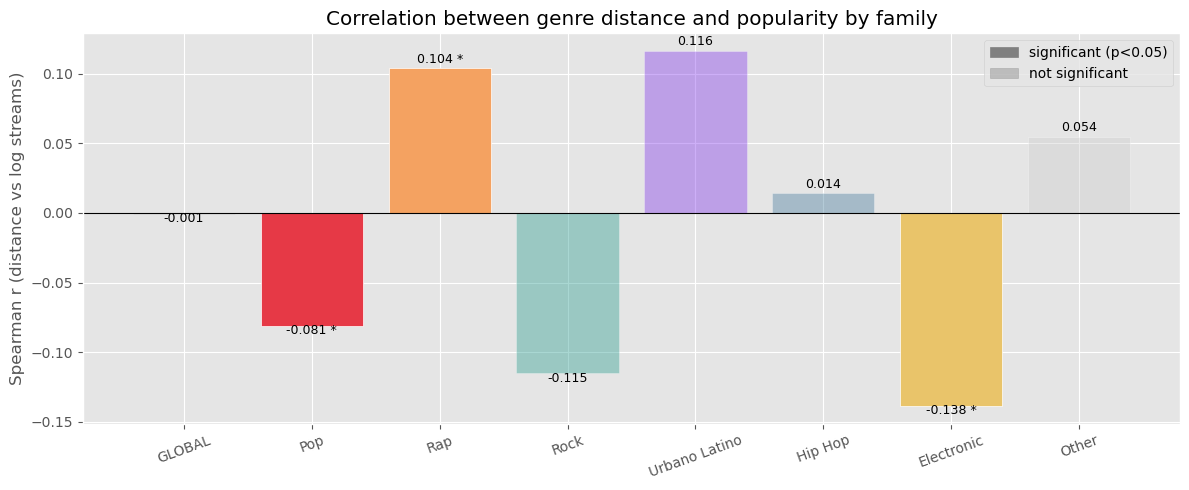

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

families = [r['Family'] for r in results]
rhos     = [r['Spearman r'] for r in results]
sig      = [r['Significant'].startswith('yes') for r in results]
colors   = ['#888' if f == 'GLOBAL' else COLORS.get(f, '#ccc') for f in families]

bars = ax.bar(families, rhos, color=colors, edgecolor='white', linewidth=0.5)
for bar, s in zip(bars, sig):
    bar.set_alpha(1.0 if s else 0.4)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Spearman r (distance vs log streams)')
ax.set_title('Correlation between genre distance and popularity by family')
ax.tick_params(axis='x', rotation=20)

for bar, r, s in zip(bars, rhos, sig):
    label = f'{r:.3f}' + (' *' if s else '')
    offset = 0.002 if r >= 0 else -0.008
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
            label, ha='center', va='bottom', fontsize=9)

sig_patch   = mpatches.Patch(color='gray', alpha=1.0, label='significant (p<0.05)')
insig_patch = mpatches.Patch(color='gray', alpha=0.4, label='not significant')
ax.legend(handles=[sig_patch, insig_patch], fontsize=10)

plt.tight_layout()
# plt.savefig('segment_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

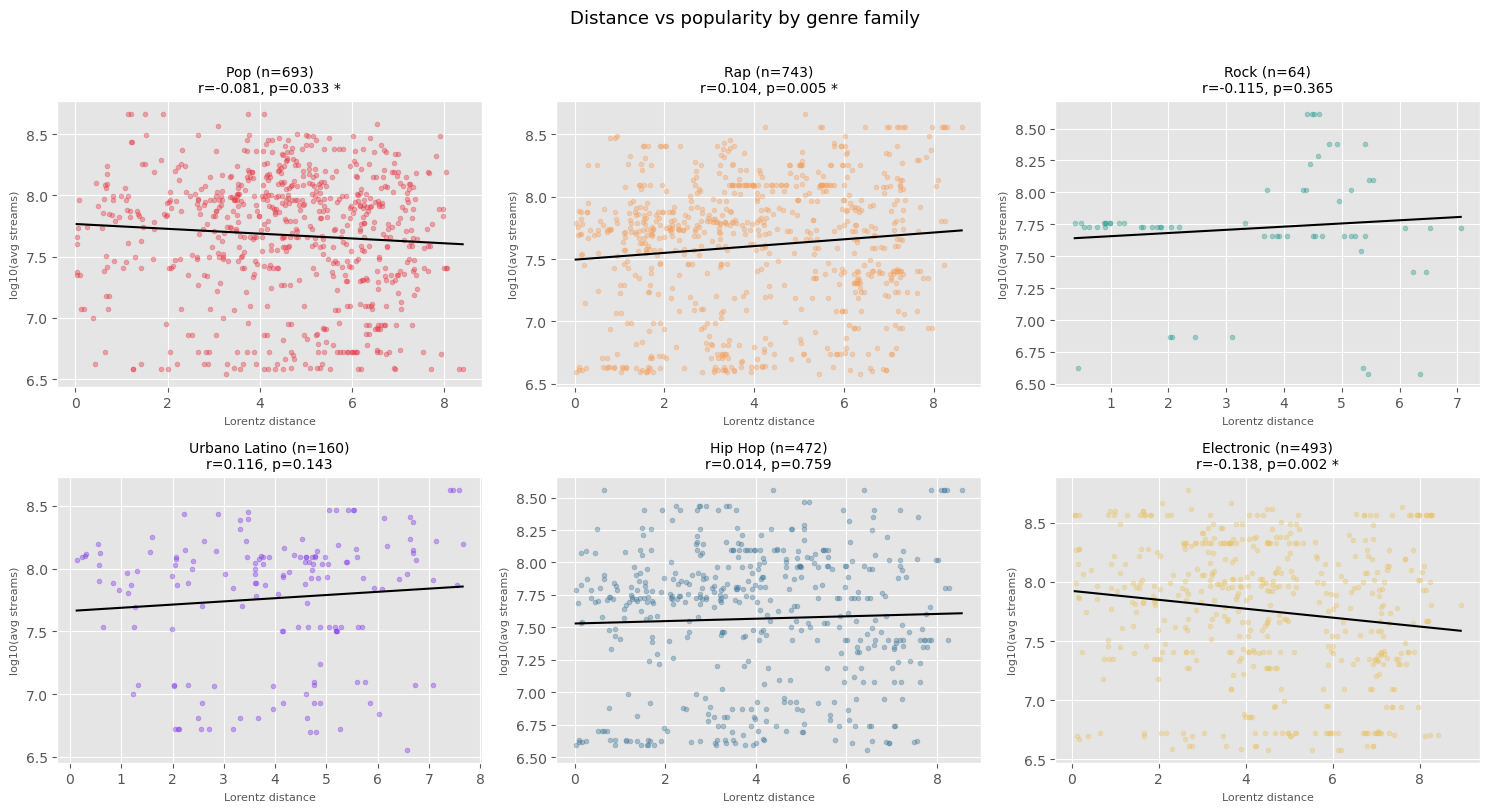

In [7]:
families_to_plot = [f for f in FAMILIES.keys()
                    if len(df_expanded[df_expanded['family'] == f]) >= 20]

n = len(families_to_plot)
cols = 3
rows_count = (n + cols - 1) // cols
fig, axes = plt.subplots(rows_count, cols, figsize=(15, 4 * rows_count))
axes = axes.flatten()

for ax, family in zip(axes, families_to_plot):
    subset = df_expanded[df_expanded['family'] == family]
    r, p = stats.spearmanr(subset['distance'], subset['log_streams'])
    color = COLORS.get(family, '#888')

    ax.scatter(subset['distance'], subset['log_streams'],
               alpha=0.4, s=12, color=color)
    z = np.polyfit(subset['distance'], subset['log_streams'], 1)
    x_line = np.linspace(subset['distance'].min(), subset['distance'].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), color='black', linewidth=1.5)

    sig_str = ' *' if p < 0.05 else ''
    ax.set_title(f'{family} (n={len(subset)})\nr={r:.3f}, p={p:.3f}{sig_str}', fontsize=10)
    ax.set_xlabel('Lorentz distance', fontsize=8)
    ax.set_ylabel('log10(avg streams)', fontsize=8)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Distance vs popularity by genre family', fontsize=13, y=1.01)
plt.tight_layout()
# plt.savefig('segment_scatters.png', dpi=150, bbox_inches='tight')
plt.show()